https://github.com/FabricioArendTorres/FlowConductor/tree/main

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os
import numpy as np
import matplotlib.pyplot as plt

import torch

from msi.flow_conductor import architecture
from msi.flow_conductor.likelihood_flow import LikelihoodFlow
from msi.utils import preprocessing
from msfm.utils import prior, parameters, files, logger

24-03-25 01:25:02   imports.py INF   Setting up healpy to run on 256 CPUs 
24-03-25 01:25:03   imports.py INF   Setting up healpy to run on 256 CPUs 


# load network predictions

### v4

In [3]:
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/config.yaml")
# base_dir = "/pscratch/sd/a/athomsen/run_files/v4"

# # lensing only

# # large_scales (6 Mpc/h)
# model_dir = "2023-08-28_04-29-33_resnet_vanilla"

# n_steps = 50000
# params = ["Om", "s8", "Aia", "n_Aia"]

In [4]:
# # combined probes
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v6/linear_bias.yaml")
# base_dir = "/pscratch/sd/a/athomsen/run_files/v4"

# # all parameters
# model_dir = "2023-08-31_03-29-47_resnet_vanilla"

# n_steps = 20000
# params = ["Om", "s8", "H0", "Ob", "ns", "w0", "Aia", "n_Aia", "bg", "n_bg"]

### v6

#### lensing only

In [5]:
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v6/linear_bias.yaml")
# # base_dir = "/pscratch/sd/a/athomsen/run_files/v6/lensing_only"
# base_dir = "/pscratch/sd/a/athomsen/run_files/v6/lensing"

# # delta loss #####################################################################################################

# # longest run, 300k steps with evaluations every 10k
# # model_dir = "delta/2024-01-12_19-35-59_resnet_vanilla"

# # model_dir = "delta/2024-02-06_11-02-57_resnet_vanilla"
# # model_dir = "delta/2024-02-08_08-21-34_resnet_vanilla"

# # biggest run yet, 100k, 200k and 300k evaluations
# # model_dir = "delta/2024-02-09_05-23-03_resnet_vanilla"

# # new, smaller run with evaluations every 10k steps (cashed, buggy)
# # model_dir = "delta/2024-02-12_00-37-01_resnet_vanilla"

# # model_dir = "delta/2024-02-12_06-56-43_resnet_vanilla"

# # new, smaller run with evaluations every 10k steps 
# # model_dir = "likelihood/2024-02-12_02-26-58_resnet_vanilla"

# # vision transformer, delta loss
# # model_dir = "delta/2024-02-13_07-42-20_vit_vanilla"

# # graph transformer, delta loss
# # model_dir = "delta/2024-02-14_02-57-06_gt_vanilla"

# # 1d convolutions, delta loss
# # model_dir = "delta/2024-02-14_01-54-13_oneD_vanilla"

# # with warmup and cosine decay for 100k steps
# model_dir = "lensing/delta/2024-02-22_03-37-44_resnet_vanilla"

# # likelihood loss ################################################################################################

# model_dir = "likelihood/2024-01-22_05-29-26_resnet_vanilla"

# # vision transformer
# # model_dir = "likelihood/2024-02-15_02-41-25_vit_vanilla"


# n_steps = 200000
# params = ["Om", "s8", "w0", "Aia", "n_Aia"]

#### clustering only

#### combined probes

In [6]:
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v6/linear_bias.yaml")
# base_dir = "/pscratch/sd/a/athomsen/run_files/v6/combined"

# # delta loss
# # model_dir = "delta/2024-02-02_00-28-48_resnet_vanilla"


# # likelihood loss
# # model_dir = "likelihood/2024-01-30_07-41-40_resnet_vanilla"
# model_dir = "likelihood/2024-02-01_09-02-59_resnet_vanilla"

# n_steps = 200000
# # params = ["Om", "s8", "H0", "Ob", "ns", "w0", "Aia", "n_Aia", "bg", "n_bg"]
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bg", "n_bg"]

# v7

### lensing only

In [7]:
conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v7/linear_bias.yaml")
base_dir = "/pscratch/sd/a/athomsen/run_files/v7/lensing"

# delta loss #####################################################################################################

# # with warmup and cosine decay for 100k steps
# model_dir = "delta/2024-02-22_03-37-44_resnet_vanilla"

# # with warmup, cosine decay and validation loss, but crashed after 80k steps (visionary-grass-327)
# model_dir = "delta/2024-02-29_04-19-40_resnet_vanilla"

# # like the above, but without validation loss (wobbly-durian-328)
# model_dir = "delta/2024-02-29_05-09-44_resnet_vanilla"

# # constant learning rate and validation loss for 100k steps (noble-snowball-334)
# model_dir = "delta/2024-03-02_10-21-45_resnet_vanilla"


# icy-vortex-344, cosine decay, but reasonable validation loss, jac_weight = 10
# training loss = -65.46736907958984
# validation loss = -18.688838958740234
# model_dir = "delta/2024-03-13_03-40-37_resnet_vanilla"

# skilled-salad-343, cosine decay, but reasonable validation loss, jac_weight = 100
# training loss = -58.87385559082031
# validation loss = -19.380346298217773
# model_dir = "delta/2024-03-13_03-40-30_resnet_vanilla"

# curant-cobbler-377, cosine decay, jac_weight = 100, no second to last MLP layer in the regression head
# training loss = -61.6363525390625
# validation loss = -17.869802474975586
# model_dir = "delta/2024-03-14_10-10-52_resnet_vanilla"

# bright-yogurt-408, cosine decay, jac_weight = 100, convolutional regression head (only difference compared to skilled-salad-343)
# training loss = -64.59732055664062
# validation loss = -18.545400619506836
# model_dir = "delta/2024-03-15_08-48-50_resnet_vanilla"

# polwar-meadow-494, ViT with small patch size
# model_dir = "delta/2024-03-22_01-19-27_resnet_vanilla"

# daily-cloud-495, ViT with larger patch size
model_dir = "delta/2024-03-22_01-19-30_resnet_vanilla"

# likelihood loss ################################################################################################

# # constant learning rate and validation for 100k steps (classic-capybara-333)
# model_dir = "likelihood/2024-03-01_13-43-31_resnet_vanilla"

n_steps = 100000
# n_steps = 101485
params = ["Om", "s8", "w0", "Aia", "n_Aia"]

### general

In [8]:
with h5py.File("/pscratch/sd/a/athomsen/run_files/v7/lensing/delta/2024-03-14_10-10-52_resnet_vanilla/preds_100000.h5", "r") as f:
    print(f.keys())

<KeysViewHDF5 ['fiducial', 'grid']>


In [9]:
# dataset
fidu_preds, grid_preds, grid_cosmos, file_dict = preprocessing.get_reshaped_network_preds(
    base_dir, model_dir, n_steps, n_params=len(params)
)

# output directory and file names
out_dir = os.path.join(base_dir, model_dir)
label = f"{n_steps}_steps"

24-03-25 01:25:04 input_output INF   Array shapes: 
24-03-25 01:25:04 input_output INF   fiducial/vali/pred = (240, 5) 
24-03-25 01:25:04 input_output INF   fiducial/vali/i_example = (240,) 
24-03-25 01:25:04 input_output INF   fiducial/vali/i_noise = (240,) 
24-03-25 01:25:04 input_output INF   grid/pred          = (2500, 48, 5) 
24-03-25 01:25:04 input_output INF   grid/cosmo         = (2500, 5) 
24-03-25 01:25:04 input_output INF   grid/i_example     = (2500, 48) 
24-03-25 01:25:04 input_output INF   grid/i_noise       = (2500, 48) 
24-03-25 01:25:04 input_output INF   grid/i_sobol       = (2500,) 


24-03-25 01:25:04 preprocessin INF   Shapes after concatenation and selection: 
24-03-25 01:25:04 preprocessin INF   fidu_preds  = (240, 5) 
24-03-25 01:25:04 preprocessin INF   grid_preds  = (120000, 5) 
24-03-25 01:25:04 preprocessin INF   grid_cosmos = (120000, 5) 


# likelihood Flow $p(x|\theta)$

### architecture

In [10]:
# input dimensions
x_dim = grid_preds.shape[-1]
theta_dim = grid_cosmos.shape[-1]

# shared hyperparameters
context_embedding_dim = 32

embedding_net = architecture.get_context_embedding_net(
    context_dim=theta_dim,
    context_embedding_dim=context_embedding_dim,
    hidden_dim=64,
    n_blocks=3,
    dropout_probability=0.0,
    use_batch_norm=False,
)    

base_dist = architecture.get_normal_dist(
    feature_dim=x_dim,
)

transform = architecture.get_sigmoids_transform(
    feature_dim=x_dim,
    context_embedding_dim=context_embedding_dim,
    n_layers=4,
    hidden_dim=256,
    svd_kwargs={},
    sigmoids_kwargs={
        "n_sigmoids": 32,
        "num_blocks": 3,
        "dropout_probability": 0.0,
    }
)

# transform = architecture.get_lipschitz_transform(
#     feature_dim=x_dim,
#     context_embedding_dim=context_embedding_dim,
#     n_layers=4,
#     hidden_dim=256,
# )

flow = LikelihoodFlow(
    params, 
    conf, 
    embedding_net=embedding_net,
    base_dist=base_dist,
    transform=transform,
    out_dir=out_dir, 
    label=label,
    load_existing=False,
)

24-03-25 01:25:04 likelihood_b INF   Set up the model directory /pscratch/sd/a/athomsen/run_files/v7/lensing/delta/2024-03-22_01-19-30_resnet_vanilla/100000_steps/likelihood_flow 
24-03-25 01:25:04 likelihood_f INF   Initialized the normalizing flow 
24-03-25 01:25:05 likelihood_f INF   Running on device cuda with default float torch.float32 
24-03-25 01:25:05 likelihood_f INF   Initializing fresh weights 


### training

24-03-25 01:25:06 likelihood_f INF   Using a cosine annealing scheduler with lr_min 1e-05 and T_max 200 
100%|████████████████████████████|   | 200/200 [04:15<00:00,  1.28s/it]       lr: 1.00E-05, train: -12.14, vali: -12.13:   
24-03-25 01:29:21 likelihood_f INF   Saved the model to /pscratch/sd/a/athomsen/run_files/v7/lensing/delta/2024-03-22_01-19-30_resnet_vanilla/100000_steps/likelihood_flow/likelihood_flow.pt 


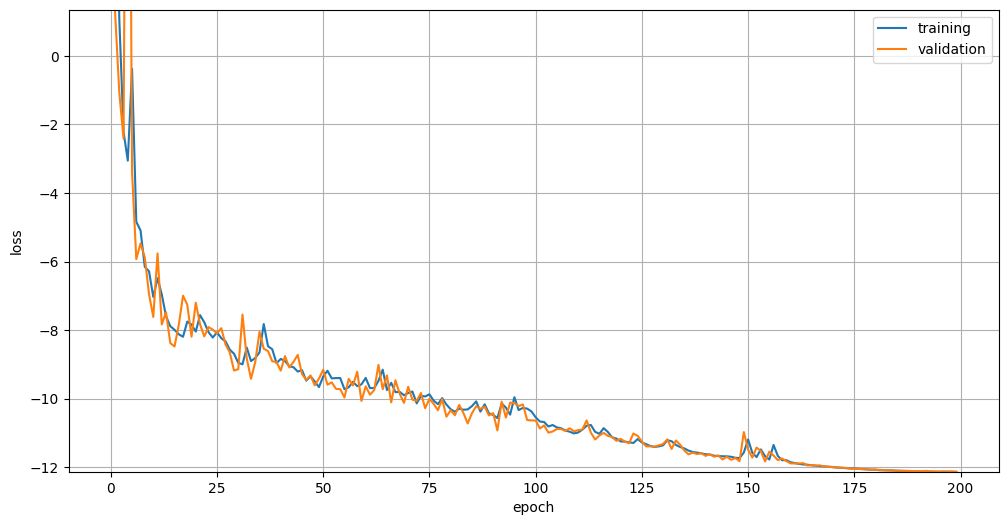

In [11]:
flow.fit(
    x=grid_preds,
    theta=grid_cosmos,
    n_epochs=200,
    # dataset
    batch_size=10000,
    vali_split=0.1,
    # optimizer
    learning_rate=1e-2,
    weight_decay=0.0,
    clip_by_global_norm=1.0,
    # scheduler
    scheduler_type="cosine",
    scheduler_kwargs={"eta_min": 1e-5},
    # early stopping
    n_patience_epochs=None,
    min_delta=1e-5,
    save_model=True,
)

In [12]:
# flow.fit(
#     x=grid_preds,
#     theta=grid_cosmos,
#     n_epochs=500,
#     # dataset
#     batch_size=10000,
#     vali_split=0.1,
#     # optimizer
#     learning_rate=1e-2,
#     weight_decay=0.0,
#     clip_by_global_norm=1.0,
#     # scheduler
#     scheduler_type="cosine",
#     scheduler_kwargs={"eta_min": 1e-5},
#     # early stopping
#     n_patience_epochs=None,
#     min_delta=1e-5,
#     save_model=True,
# )

In [13]:
# flow.fit(
#     x=grid_preds,
#     theta=grid_cosmos,
#     n_epochs=100,
#     # dataset
#     batch_size=10000,
#     vali_split=0.1,
#     # optimizer
#     learning_rate=1e-2,
#     weight_decay=0.0,
#     clip_by_global_norm=1.0,
#     # scheduler
#     scheduler_type="cosine",
#     scheduler_kwargs={"eta_min": 1e-6},
#     # early stopping
#     n_patience_epochs=None,
#     min_delta=1e-5,
#     save_model=True,
# )

# flow.fit(
#     x=grid_preds,
#     theta=grid_cosmos,
#     n_epochs=100,
#     # dataset
#     batch_size=10000,
#     vali_split=0.1,
#     # optimizer
#     learning_rate=1e-6,
#     weight_decay=0.0,
#     clip_by_global_norm=1.0,
#     # scheduler
#     scheduler_type=None,
#     # early stopping
#     n_patience_epochs=20,
#     min_delta=1e-5,
#     save_model=True,
# )

### convergence tests

24-03-25 01:29:22 likelihood_b INF   Drawing samples from the likelihood 
24-03-25 01:29:33 likelihood_b INF   Done drawing samples after 0:00:11.36 
100%|████████████████████████████|   | 2500/2500 [00:00<00:00, 10802.77it/s]  EECP: looping through cosmos
24-03-25 01:29:42 diagnostics. INF   TARP random reference points: Using the default 
100%|████████████████████████████|   | 48/48 [00:00<00:00, 101.86it/s]        TARP: looping through examples


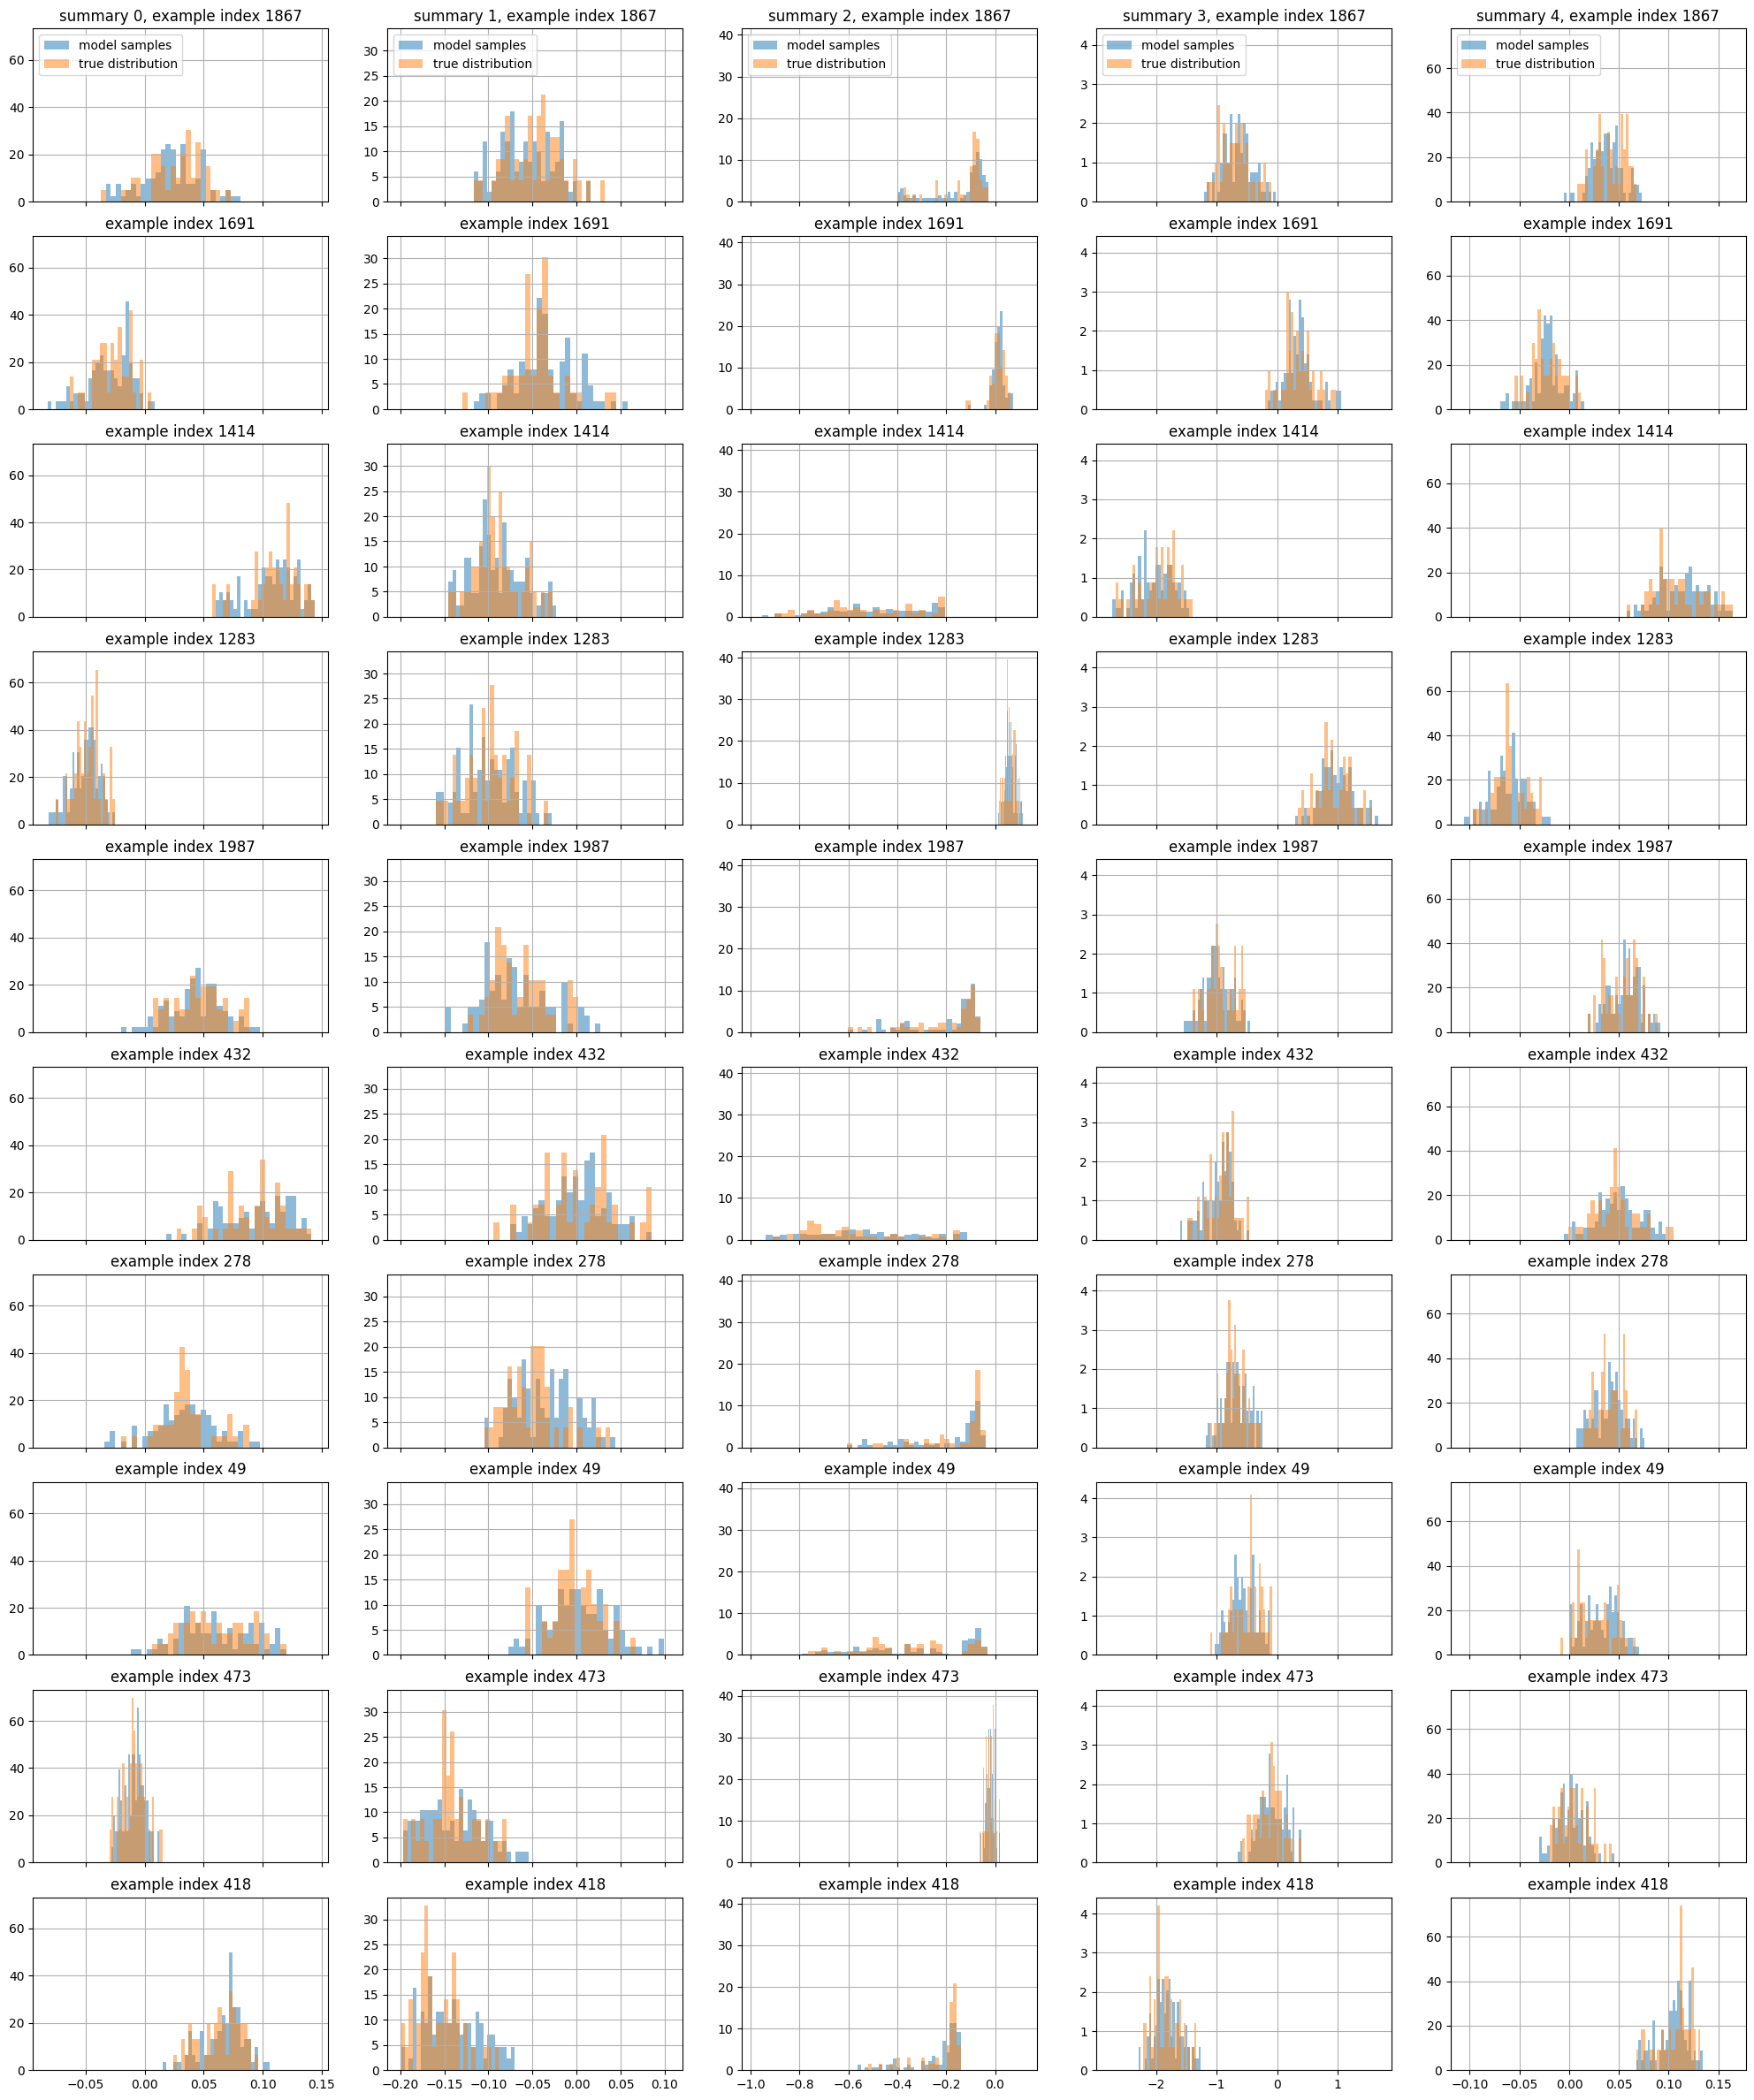

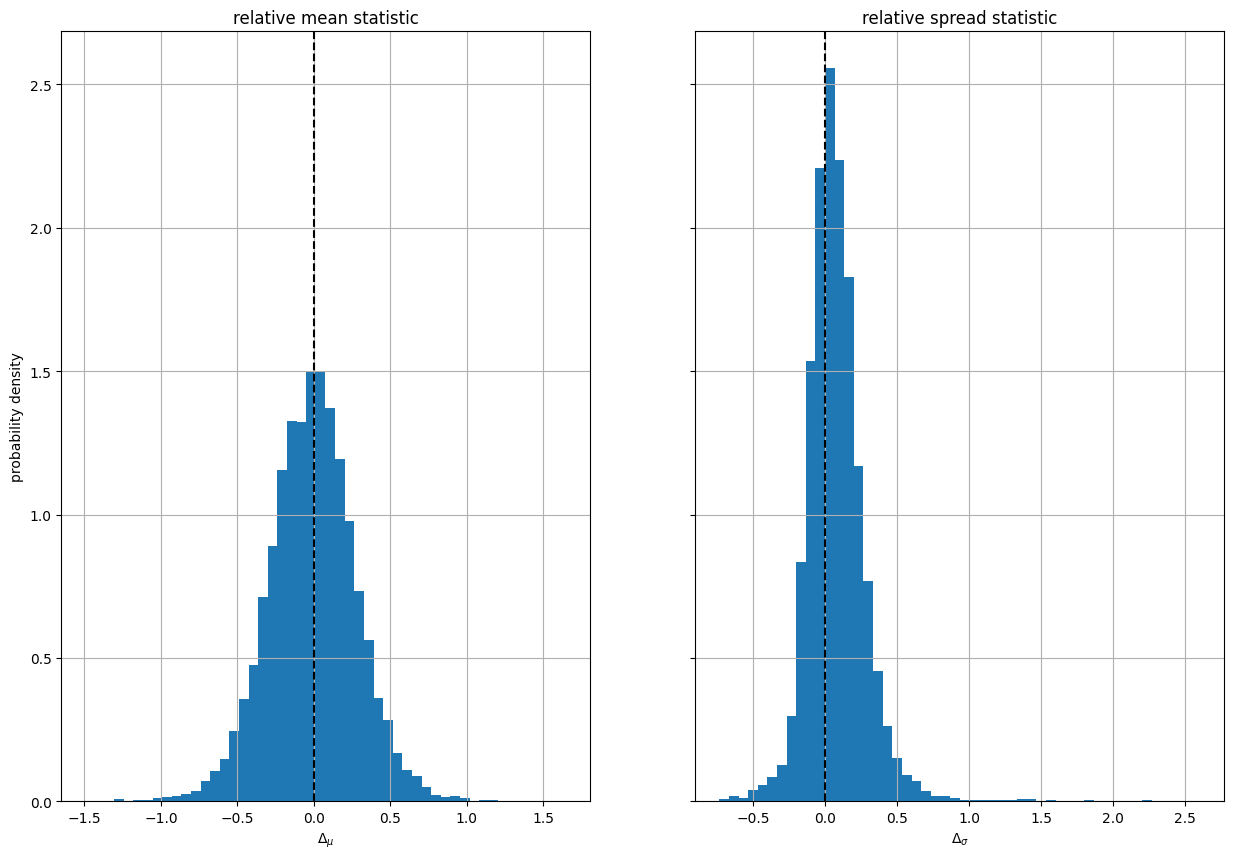

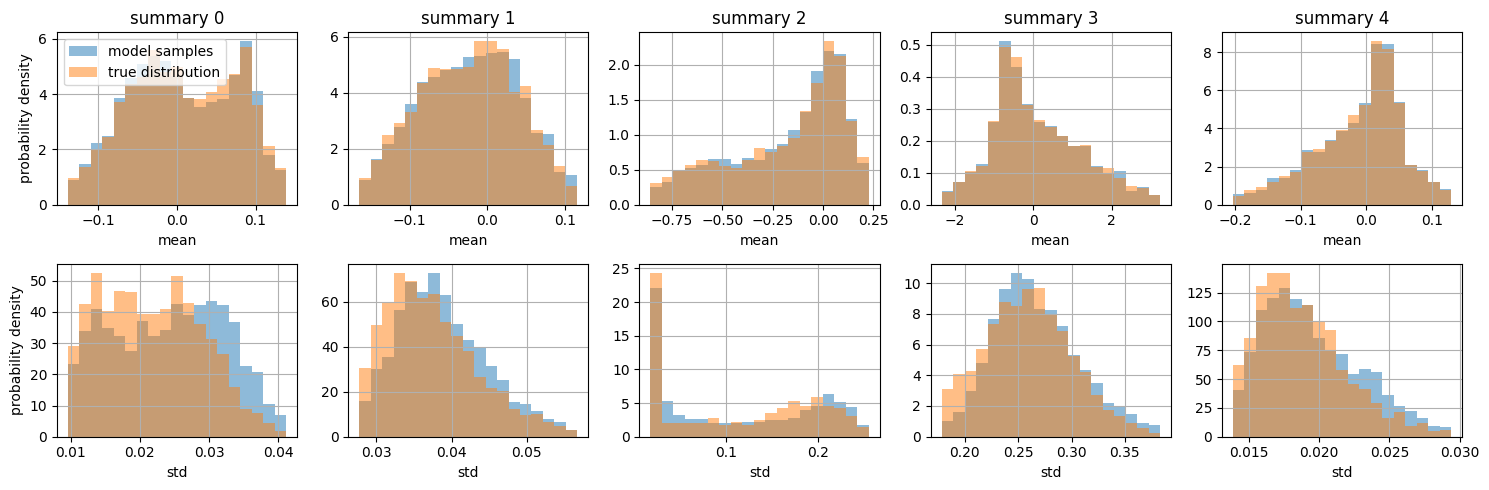

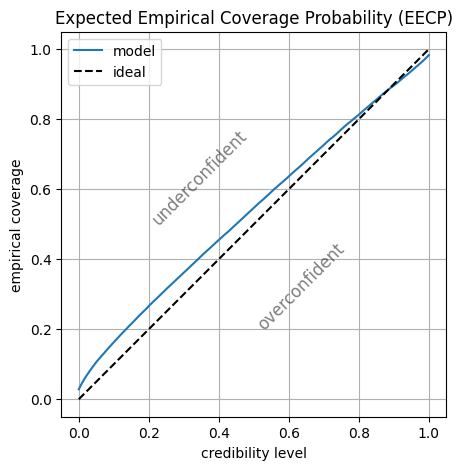

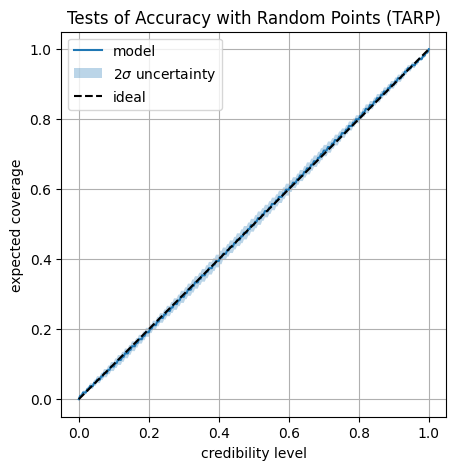

In [14]:
grid_preds_sample = flow.plot_diagnostics(
    # these must be the raw arrays where the cosmo and example axis are still separate
    grid_preds_true=file_dict["grid/pred"][...,:len(params)], 
    grid_cosmos=file_dict["grid/cosmo"],
    n_samples=100,
    # do_hist=True,
    do_dlss=True,
    do_eecp=True,
    do_tarp=True,
)

### observation

In [15]:
i_obs = 0
# i_obs = np.argmin(np.sum(np.square(np.median(fidu_preds, axis=0, keepdims=True) - fidu_preds), axis=-1))

print(f"Using the example index {i_obs}")
# obs_pred = fidu_preds[i_obs]
obs_pred = file_dict["fiducial/vali/pred"][i_obs,...,:len(params)]

print(obs_pred)

Using the example index 0
[-0.01602685 -0.01591869  0.03026073  0.5341684  -0.02677999]


### MCMC

In [16]:
posterior_samples = flow.sample_posterior(
    obs_pred,
)

24-03-25 01:29:50      mcmc.py INF   Initial values in prior: True 
24-03-25 01:29:50      mcmc.py INF   Starting the burn in MCMC chain (100 steps) 
24-03-25 01:29:55      mcmc.py INF   Starting the main MCMC chain (500 steps) 


100%|██████████| 500/500 [00:25<00:00, 19.98it/s]

24-03-25 01:30:20      mcmc.py INF   Saved the MCMC chain to /pscratch/sd/a/athomsen/run_files/v7/lensing/delta/2024-03-22_01-19-30_resnet_vanilla/100000_steps/likelihood_flow/chain.npy 


### plotting

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

24-03-25 01:30:24  plotting.py INF   Saved the plot to /pscratch/sd/a/athomsen/run_files/v7/lensing/delta/2024-03-22_01-19-30_resnet_vanilla/100000_steps/likelihood_flow/contours.png 


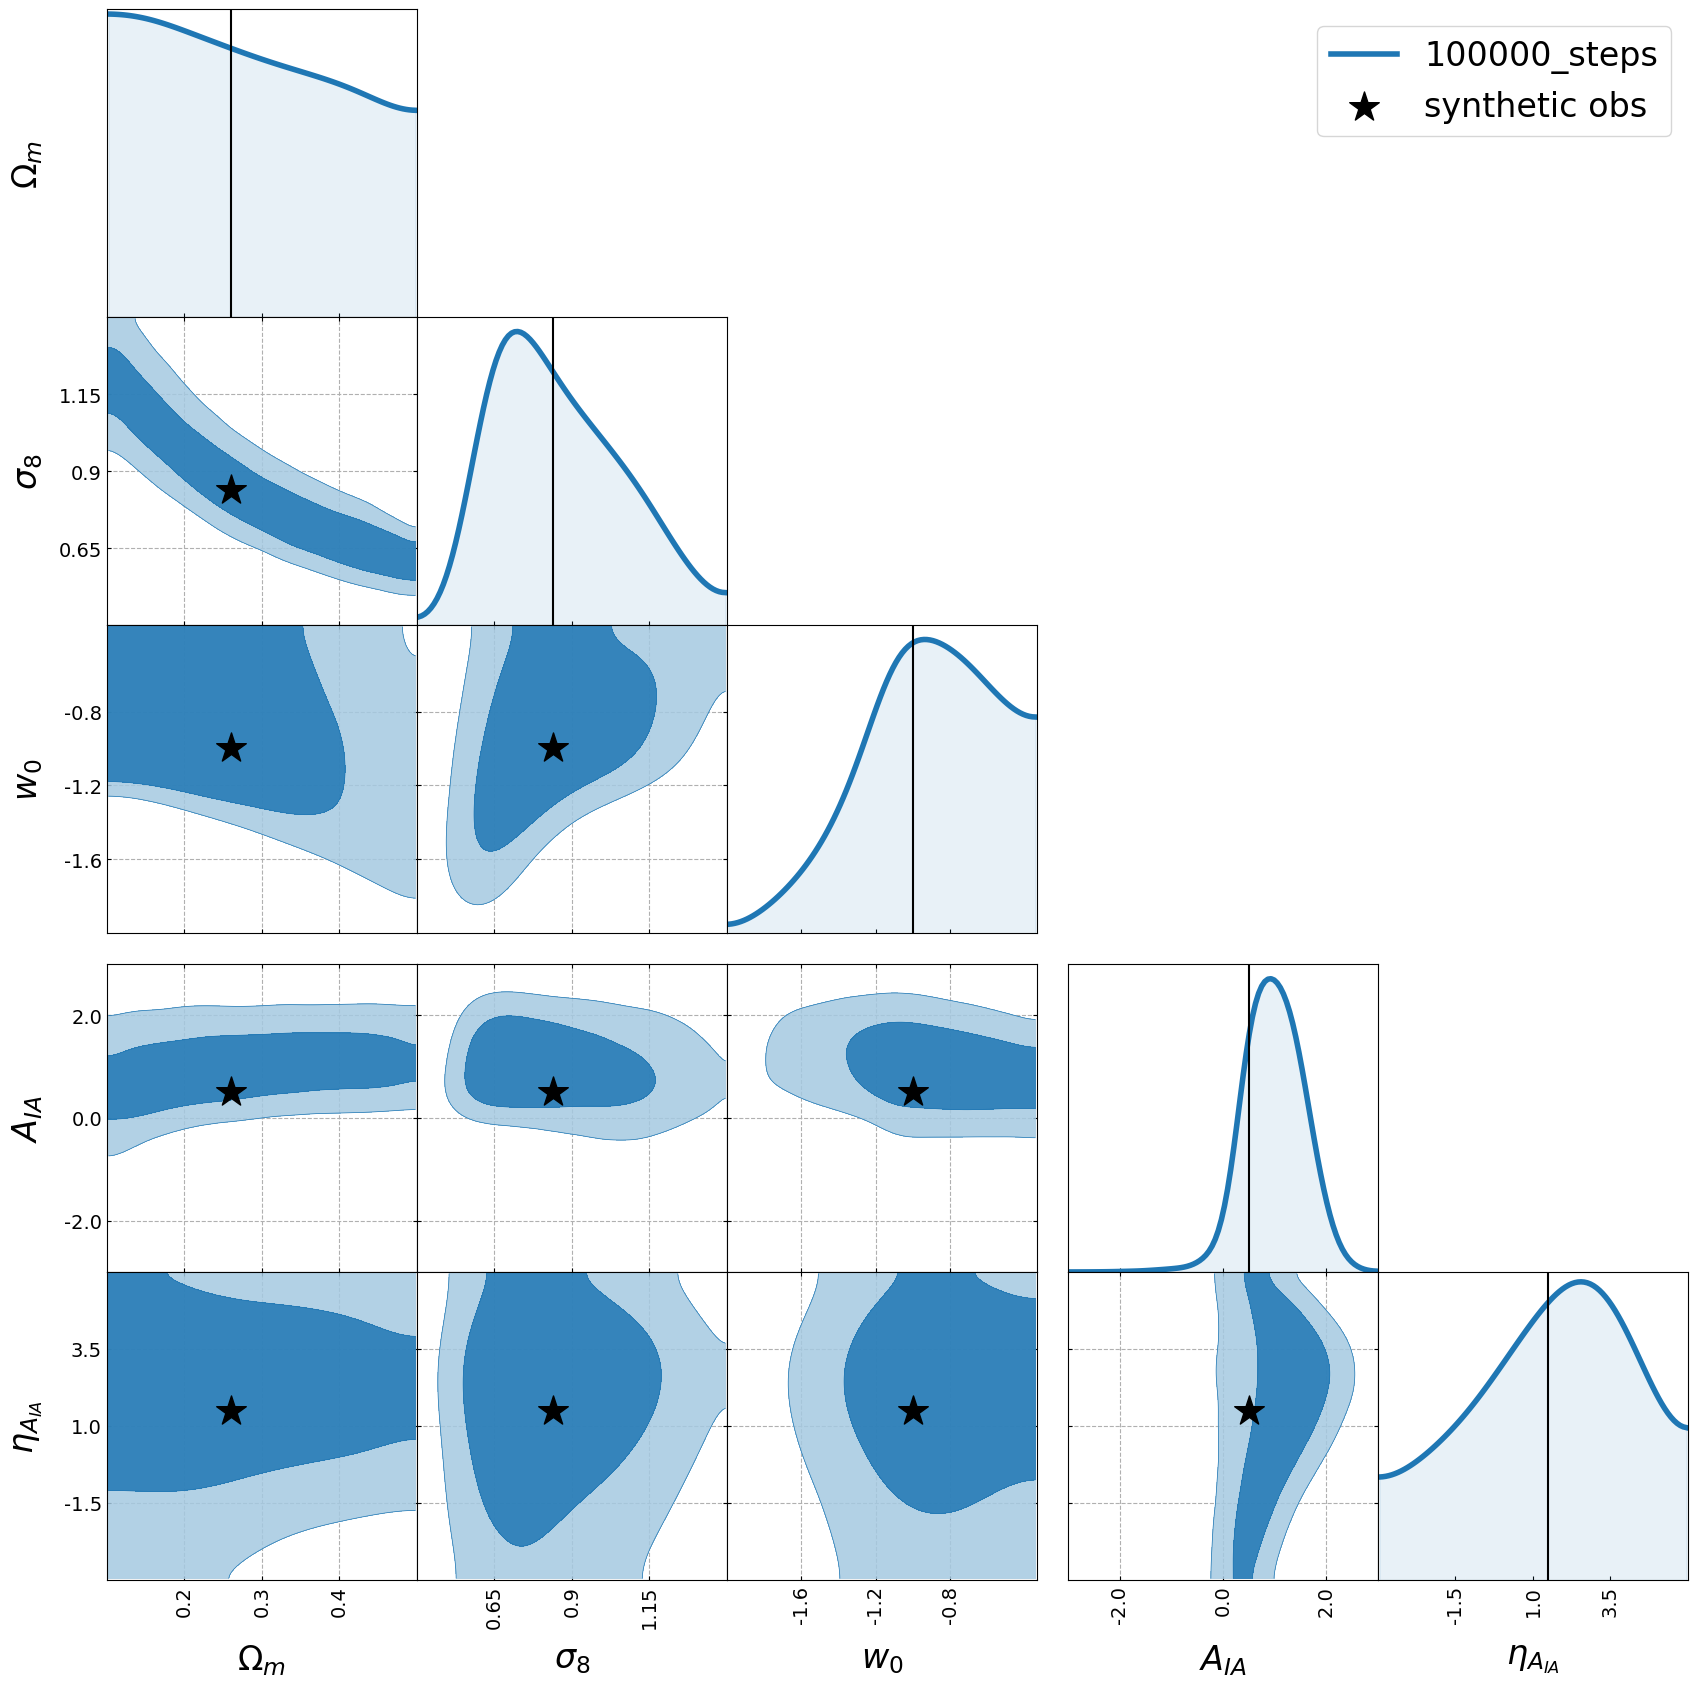

In [17]:
flow.plot_contours(
    posterior_samples,
)